# 02 Video Preprocessing & Dataset

Implementation of a memory-efficient `VideoFrameDataset` that performs in-memory frame extraction using OpenCV.

### Key Features:
- **Path Stability**: Use `PROJECT_ROOT` to resolve all paths from the project base.
- **In-Memory Extraction**: Frames are extracted on-the-fly, no storage on disk.
- **Uniform Sampling**: Exact `FRAME_COUNT` frames extracted via linear interpolation.

In [1]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
import yaml
import json
import logging

# PROJECT ROOT
PROJECT_ROOT = Path().resolve().parents[1]
print(f"Project Root: {PROJECT_ROOT}")

# CONFIG
CONFIG_PATH = PROJECT_ROOT / "configs" / "video_config.yaml"

with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

DATA_PATH = PROJECT_ROOT / config["data"]["raw_path"]
print(f"Resolved DATA_PATH: {DATA_PATH}")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset path not found: {DATA_PATH}")

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

Project Root: D:\Projects\Machine_Learning Projects\Cognito_AI_A.M
Resolved DATA_PATH: D:\Projects\Machine_Learning Projects\Cognito_AI_A.M\data\raw\videos


## 1. Hardened Discovery Utilities

In [2]:
def extract_part_number(name):
    try:
        return int(name.split('_')[-1].strip())
    except:
        return None


def discover_dataset_paths(base_path, max_part=4):  # 🔥 limit
    base_path = Path(base_path)

    valid_parts = []

    for item in os.listdir(base_path):
        item_path = base_path / item

        if item.startswith("dfdc_train_part_") and item_path.is_dir():
            part_num = extract_part_number(item)

            if part_num is not None and part_num <= max_part:
                valid_parts.append((item_path, part_num))

    valid_parts.sort(key=lambda x: x[1])

    print(f"[INFO] Using parts: {[x[1] for x in valid_parts]}")

    final_paths = []
    for path, _ in valid_parts:
        if (path / "metadata.json").exists():
            final_paths.append(path)

    return final_paths


parts = discover_dataset_paths(DATA_PATH, max_part=4)

print("\nValidated Dataset Paths:")
for p in parts:
    print(f" - {p}")

[INFO] Using parts: [0, 1, 2, 3, 4]

Validated Dataset Paths:
 - D:\Projects\Machine_Learning Projects\Cognito_AI_A.M\data\raw\videos\dfdc_train_part_0
 - D:\Projects\Machine_Learning Projects\Cognito_AI_A.M\data\raw\videos\dfdc_train_part_1
 - D:\Projects\Machine_Learning Projects\Cognito_AI_A.M\data\raw\videos\dfdc_train_part_2
 - D:\Projects\Machine_Learning Projects\Cognito_AI_A.M\data\raw\videos\dfdc_train_part_3
 - D:\Projects\Machine_Learning Projects\Cognito_AI_A.M\data\raw\videos\dfdc_train_part_4


## 2. VideoFrameDataset Class

In [3]:
def collect_video_info(parts_paths):
    data = []

    for part_path in tqdm(parts_paths, desc="Scanning Parts"):
        metadata_path = part_path / "metadata.json"

        try:
            with open(metadata_path, "r") as f:
                metadata = json.load(f)
        except:
            continue

        for filename, info in metadata.items():
            video_path = part_path / filename

            if video_path.exists():
                data.append({
                    "path": str(video_path),
                    "part": part_path.name,
                    "label": info["label"],
                    "label_id": 1 if info["label"] == "FAKE" else 0
                })

    return pd.DataFrame(data)


if parts:
    df = collect_video_info(parts)
    print(f"[INFO] Total videos: {len(df)}")
    display(df.head())
else:
    print("No parts found.")

Scanning Parts:   0%|          | 0/5 [00:00<?, ?it/s]

[INFO] Total videos: 7937


,path,part,label,label_id
0,D:\Projects\Machine_Learning Projects\Cognito_...,dfdc_train_part_0,FAKE,1
1,D:\Projects\Machine_Learning Projects\Cognito_...,dfdc_train_part_0,REAL,0
2,D:\Projects\Machine_Learning Projects\Cognito_...,dfdc_train_part_0,REAL,0
3,D:\Projects\Machine_Learning Projects\Cognito_...,dfdc_train_part_0,FAKE,1
4,D:\Projects\Machine_Learning Projects\Cognito_...,dfdc_train_part_0,FAKE,1


## 3. DataLoader Setup & Test

Class Distribution:
label
FAKE    7111
REAL     826
Name: count, dtype: int64


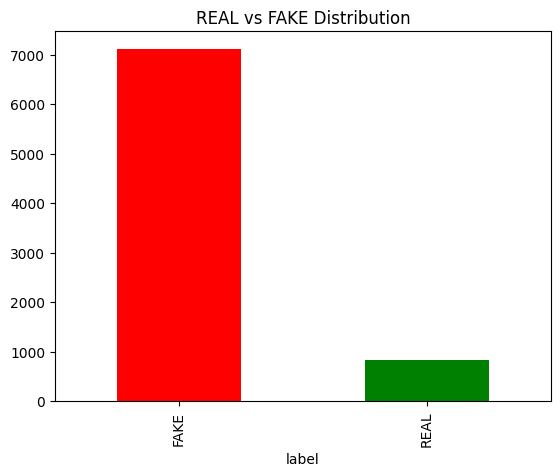

Using device: cuda


c:\Users\Asus\miniconda3\envs\deepfake\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Asus\miniconda3\envs\deepfake\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ GPU forward pass working
Tensor device: cuda:0


In [4]:
if 'df' in locals() and not df.empty:
    dist = df["label"].value_counts()

    print("Class Distribution:")
    print(dist)

    dist.plot(kind="bar", color=['red', 'green'])
    plt.title("REAL vs FAKE Distribution")
    plt.show()

# 🔥 GPU TEST (THIS WAS MISSING BEFORE)
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

IMG_SIZE = config["model"]["frame_size"]
FRAME_COUNT = config["model"]["frame_count"]

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

class VideoFrameDataset(Dataset):
    def __init__(self, video_list, num_frames=32, transform=None):
        self.video_list = video_list
        self.num_frames = num_frames
        self.transform = transform

    def __len__(self):
        return len(self.video_list)

    def __getitem__(self, index):
        path, label = self.video_list[index]

        cap = cv2.VideoCapture(path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        indices = np.linspace(0, total - 1, self.num_frames).astype(int)
        frames = []

        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()

            if not ret:
                frame = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

            frame = Image.fromarray(frame)

            if self.transform:
                frame = self.transform(frame)

            frames.append(frame)

        cap.release()

        return torch.stack(frames), torch.tensor(label, dtype=torch.float32)


# 🔥 build small test batch
sample_videos = [(row["path"], row["label_id"]) for _, row in df.head(5).iterrows()]

dataset = VideoFrameDataset(sample_videos, FRAME_COUNT, transform)
loader = DataLoader(dataset, batch_size=2, pin_memory=True)

frames, labels = next(iter(loader))

# 🔥 simple model test
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

frames = frames.to(device)

B, T, C, H, W = frames.shape
frames = frames.view(B*T, C, H, W)

with torch.no_grad():
    out = model(frames)

print("✅ GPU forward pass working")
print(f"Tensor device: {frames.device}")